# HW 16: NLP+LSTM. Plotting the results

In [1]:
import re
import logging
import time

from bs4 import BeautifulSoup
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm_notebook

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    LSTM,
    GRU,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.datasets import imdb
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import get_file
import pickle
from tqdm.notebook import tqdm

In [3]:
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

In [4]:
def plot_history(history):
    history_dict = history.history
    loss_values = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    epochs = range(1, len(loss_values) + 1)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.plot(epochs, loss_values, 'bo',
             label='Training loss')
    ax1.plot(epochs, val_loss_values, 'b',
             label='Validation loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_xscale('log')

    acc_values = history_dict['accuracy']
    val_acc_values = history_dict['val_accuracy']

    ax2.plot(epochs, acc_values, 'bo',
             label='Training acc')
    ax2.plot(epochs, val_acc_values, 'b',
             label='Validation acc')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_xscale('log')


    plt.legend()
    plt.show()

## Getting training histories from pickle files

In [13]:
all_hist = {}

In [2]:
with open('data/lstm_hist_16f.pkl', 'rb') as handle:
    all_hist['16f'] = pickle.load(handle)

In [15]:
with open('data/lstm_hist_32f.pkl', 'rb') as handle:
    all_hist['32f'] = pickle.load(handle)

In [16]:
with open('data/lstm_hist_128f.pkl', 'rb') as handle:
    all_hist['128f'] = pickle.load(handle)

### Plotting loss histories

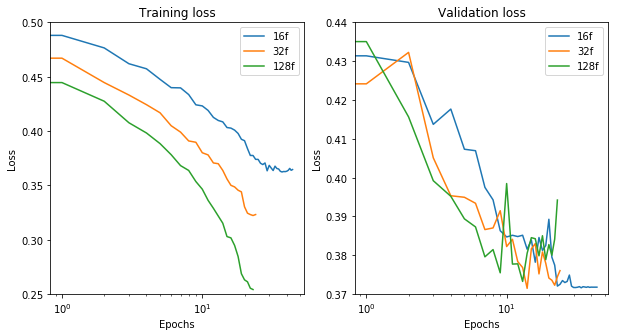

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

[ax1.plot(range(len(all_hist[k]['loss'])), all_hist[k]['loss'],
         label=k) for k in all_hist.keys()]
ax1.legend()
ax1.set_title('Training loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xscale('log')
ax1.set_ylim((0.25, 0.5))

[ax2.plot(range(len(all_hist[k]['val_loss'])), all_hist[k]['val_loss'],
         label=k) for k in all_hist.keys()]
ax2.legend()
ax2.set_title('Validation loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_xscale('log')
ax2.set_ylim((0.37, 0.44))


plt.legend()
plt.show()

### Plotting accuracy histories

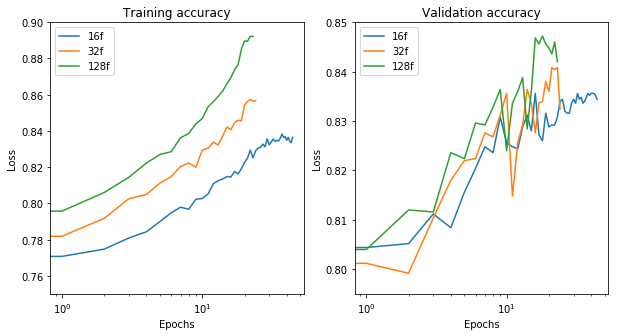

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

[ax1.plot(range(len(all_hist[k]['accuracy'])), all_hist[k]['accuracy'],
         label=k) for k in all_hist.keys()]
ax1.legend()
ax1.set_title('Training accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xscale('log')
ax1.set_ylim((0.75, 0.9))

[ax2.plot(range(len(all_hist[k]['val_accuracy'])), all_hist[k]['val_accuracy'],
         label=k) for k in all_hist.keys()]
ax2.legend()
ax2.set_title('Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_xscale('log')
ax2.set_ylim((0.795, 0.85))


plt.legend()
plt.show()

Seems like the more word2vec embedding features == the better. However, one cannot increase this value indefinitely due to limited memory size